<a href="https://colab.research.google.com/github/cara-jvr/mit-805-group-project/blob/main/notebooks/Group12_01_Data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MIT 805 Big Data Project** <br>
Group 12 <br>
Unarine <br>
Cara Janse van Rensburg (18002189)

**1. Start-Up:** Creating Spark Session and importing required libraries

In [47]:
from pyspark.sql import SparkSession

# creating a Spark Session Object
spark = (
    SparkSession.builder
    .appName("Big-Data-Project")
    .master("local[*]")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)
sc = spark.sparkContext
spark

In [48]:
# import libraries
from pyspark.sql.functions import split, explode, col, desc, sum as _sum, when, count, to_timestamp, lit, datediff, timestamp_diff, unix_timestamp
from pyspark.sql import functions as F
import pyarrow.parquet as pq
import glob
import pandas as pd
import os
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt

**2. Loading the data**

In [49]:
# reading files from Google Drive
drive.mount('/content/drive')
file_path = "drive/MyDrive/Big_data_project/data"
os.listdir(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['fhvhv_tripdata_2023-01.parquet',
 'fhvhv_tripdata_2023-02.parquet',
 'fhvhv_tripdata_2023-03.parquet',
 'fhvhv_tripdata_2023-04.parquet',
 'fhvhv_tripdata_2023-05.parquet',
 'fhvhv_tripdata_2023-06.parquet',
 'fhvhv_tripdata_2023-08.parquet',
 'fhvhv_tripdata_2023-09.parquet',
 'fhvhv_tripdata_2023-11.parquet',
 'fhvhv_tripdata_2023-12.parquet',
 'fhvhv_tripdata_2023-07.parquet',
 'fhvhv_tripdata_2023-10.parquet']

In [50]:
df = spark.read.parquet(file_path)

**3. Dataset Characteristics**

In [51]:
# Getting the column names and data types
df.printSchema()

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_ride_f

In [52]:
# number of rows
rows = df.count()
print(f"Number of rows: {rows/10**6} million")

Number of rows: 232.49002 million


In [53]:
# size of compressed raw file
compressed_gb = 0

for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith(".parquet"):
            compressed_gb += os.path.getsize(os.path.join(root, file))

total_gb = compressed_gb / (1024**3)

print(f"Total dataset size: {total_gb:.2f} GB")

Total dataset size: 5.42 GB


In [54]:
# size of uncompressed raw file

def get_parquet_uncompressed_size(file_path):
    """Extracts the total uncompressed size from a Parquet file footer metadata."""
    try:
        # Read only the metadata footer, avoiding loading the actual data into memory
        metadata = pq.read_metadata(file_path)

        # Sum up the uncompressed size of all row groups
        total_bytes = sum(metadata.row_group(i).total_byte_size for i in range(metadata.num_row_groups))
        return total_bytes
    except Exception as e:
        print(f"Error reading metadata for {file_path}: {e}")
        return 0

total_uncompressed_bytes = 0
file_count = 0

# Recursively walk through the directory tree
for root, dirs, files in os.walk(file_path):
    for file in files:
        if file.endswith('.parquet') or file.endswith('.parq'):
            full_path = os.path.join(root, file)

            # Get the uncompressed size in bytes
            uncompressed_bytes = get_parquet_uncompressed_size(full_path)
            total_uncompressed_bytes += uncompressed_bytes
            file_count += 1

            # Convert bytes to Gigabytes (GB)
            size_in_gb = uncompressed_bytes / (1024 ** 3)

            # Print individual file metrics (truncated names for alignment)
            display_name = file if len(file) <= 47 else f"...{file[-44:]}"
            print(f"{display_name:<50} | {size_in_gb:>21.4f} GB")

# Final summary conversion
total_uncompressed_gb = total_uncompressed_bytes / (1024 ** 3)

print("=" * 75)
print(f"Total Parquet Files Found: {file_count}")
print(f"Total Uncompressed Size:   {total_uncompressed_gb:.4f} GB")


fhvhv_tripdata_2023-01.parquet                     |                0.7929 GB
fhvhv_tripdata_2023-02.parquet                     |                0.7651 GB
fhvhv_tripdata_2023-03.parquet                     |                0.8706 GB
fhvhv_tripdata_2023-04.parquet                     |                0.8126 GB
fhvhv_tripdata_2023-05.parquet                     |                0.8499 GB
fhvhv_tripdata_2023-06.parquet                     |                0.8261 GB
fhvhv_tripdata_2023-08.parquet                     |                0.5358 GB
fhvhv_tripdata_2023-09.parquet                     |                0.5454 GB
fhvhv_tripdata_2023-11.parquet                     |                0.5366 GB
fhvhv_tripdata_2023-12.parquet                     |                0.5570 GB
fhvhv_tripdata_2023-07.parquet                     |                0.8181 GB
fhvhv_tripdata_2023-10.parquet                     |                0.5614 GB
Total Parquet Files Found: 12
Total Uncompressed Size:   8.4715 

In [55]:
df.limit(1).show()

+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|   request_datetime|  on_scene_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls| bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|
+-----------------+--------------------+--------------------+-------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+--

In [56]:
file_path = "drive/MyDrive/Big_data_project/data/fhvhv_tripdata_2023-01.parquet"

# Load the file into a Spark DataFrame
df = spark.read.parquet(file_path)

In [58]:
#Data date range
df.select(
    F.min("pickup_datetime"),
    F.max("pickup_datetime")
).show()

+--------------------+--------------------+
|min(pickup_datetime)|max(pickup_datetime)|
+--------------------+--------------------+
| 2023-01-01 00:00:00| 2023-01-31 23:59:59|
+--------------------+--------------------+



**4. Data Quality Analysis & Data Cleaning**

In [59]:
#Missing Values
missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing.show()

+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+
|hvfhs_license_num|dispatching_base_num|originating_base_num|request_datetime|on_scene_datetime|pickup_datetime|dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls|bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|
+-----------------+--------------------+--------------------+----------------+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+-----+---+---------+--------------------+-----------+----+----------+-------------------+-----

In [60]:
# dropping originating_base_num and on_scene_datetime columns
df = df.drop("originating_base_num", "on_scene_datetime")

In [61]:
# checking for duplicates
duplicates_df = (
    df.groupBy("hvfhs_license_num", "pickup_datetime", "dropoff_datetime","PULocationID", "DOLocationID", "trip_miles")
    .count()
    .filter(col("count") > 1)
)

duplicates_df.count()

4

In [62]:
duplicates_df.limit(2).show()

+-----------------+-------------------+-------------------+------------+------------+----------+-----+
|hvfhs_license_num|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|count|
+-----------------+-------------------+-------------------+------------+------------+----------+-----+
|           HV0005|2023-01-13 04:52:21|2023-01-13 05:01:31|         134|         132|     6.114|    2|
|           HV0005|2023-01-15 03:20:39|2023-01-15 03:28:47|         112|         148|     3.474|    2|
+-----------------+-------------------+-------------------+------------+------------+----------+-----+



In [63]:
# dropping duplicates
df_dedup = df.dropDuplicates(["hvfhs_license_num", "pickup_datetime", "dropoff_datetime","PULocationID", "DOLocationID", "trip_miles"])

In [64]:
# invalid Trip duration
df_dedup = df_dedup.withColumn(
    "trip_seconds",
     unix_timestamp(col("dropoff_datetime")) - unix_timestamp(col("pickup_datetime"))
)
df_dedup.filter(col("trip_seconds") <= 0).count()

2

In [65]:
df_dedup.filter(col("trip_seconds") <= 0).limit(5).show()

+-----------------+--------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+--------------+------------+
|hvfhs_license_num|dispatching_base_num|   request_datetime|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tolls| bcf|sales_tax|congestion_surcharge|airport_fee|tips|driver_pay|shared_request_flag|shared_match_flag|access_a_ride_flag|wav_request_flag|wav_match_flag|trip_seconds|
+-----------------+--------------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+-----+----+---------+--------------------+-----------+----+----------+-------------------+-----------------+------------------+----------------+---------

In [66]:
# removing the above invalid trips
df_dedup = df_dedup.filter(col("trip_seconds") > 0)

In [67]:
# ensuring that trip_time corresponds to (dropoff_datetime - pickup_datetime) within 1 second
df_dedup = df_dedup.withColumn(
    "seconds_diff",
     (col("trip_time") - col("trip_seconds"))
)
df_dedup = df_dedup.withColumn("absolute_diff", F.abs(df_dedup["seconds_diff"]))
df_dedup.filter((col("absolute_diff")) >1).count()

429

In [68]:
# removing more incorrect trip times
df_dedup = df_dedup.filter((col("absolute_diff")) <=1)

In [ ]:
# base passenger fare must also be positive
df_dedup = df_dedup.filter(col("base_passenger_fare") > 0)

In [69]:
# outliers (Using Interquartile Range method)
def IQR_outlier_removal(df, column_name):
  q1, q3 = df.approxQuantile(column_name, [0.25, 0.75], 0.05)
  iqr = q3 - q1
  lower_val = q1 - 1.5 * iqr
  upper_val = q3 + 1.5 * iqr
  clean_df = df.filter((col(column_name) >= lower_val) & (col(column_name) <= upper_val))
  return clean_df

df_clean1 = IQR_outlier_removal(df_dedup, "trip_time")

In [70]:
df_clean2 = IQR_outlier_removal(df_clean1, "trip_miles")
df_clean2.count()

15950433

In [71]:
# bias
# checking which pick-up locations are not attended to
PULocation_counts = df_clean2.groupBy("PULocationID").count()
PULocation_counts.orderBy(F.col("count").asc()).show(10)

# checking if a certain suburb gets charged more when there is no congestion surcharge

+------------+-----+
|PULocationID|count|
+------------+-----+
|         105|    4|
|           1|    4|
|         199|   10|
|           2|   16|
|         110|   24|
|          99|  280|
|           8|  310|
|          27|  358|
|         111|  413|
|         253|  451|
+------------+-----+
only showing top 10 rows


In [72]:
#checking which drop off zones do not get attended to
DOLocation_counts = df_clean2.groupBy("DOLocationID").count()
DOLocation_counts.orderBy(F.col("count").asc()).show(10)

+------------+-----+
|DOLocationID|count|
+------------+-----+
|         105|    8|
|           2|   15|
|         110|   38|
|           1|  193|
|           8|  276|
|          99|  340|
|         253|  432|
|         111|  527|
|          30|  562|
|          27|  637|
+------------+-----+
only showing top 10 rows


In [73]:
# check for operational time bias
df_clean2 = df_clean2.withColumn("Year", F.year("pickup_datetime")) \
              .withColumn("Month", F.month("pickup_datetime")) \
              .withColumn("Day", F.dayofmonth("pickup_datetime")) \
              .withColumn("Hour", F.hour("pickup_datetime")) \
              .withColumn("weekday_name", F.date_format("pickup_datetime", "EEEE"))

In [74]:
df_clean2.groupBy("weekday_name").count().orderBy("count", ascending=False).show()

+------------+-------+
|weekday_name|  count|
+------------+-------+
|      Sunday|2685591|
|    Saturday|2548119|
|      Friday|2292605|
|     Tuesday|2270769|
|      Monday|2102810|
|    Thursday|2096671|
|   Wednesday|1953868|
+------------+-------+



**5. Exploratory Data Analysis**

In [ ]:
# value counts for categorical columns
cat_cols1 = ["shared_request_flag", "access_a_ride_flag", "wav_request_flag", "wav_match_flag"]

for col_name in cat_cols1:
    print(f"--- Value Counts for {col_name} ---")
    df_clean2.groupBy(col_name).count().orderBy("count", ascending=False).show()

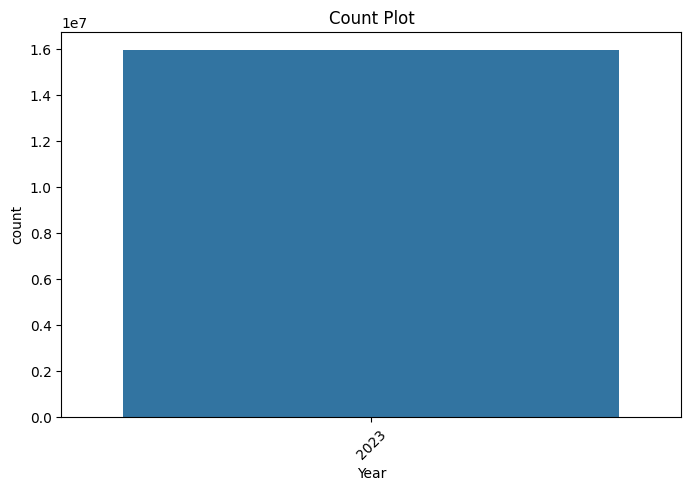

In [75]:
Year_df = df_clean2.groupBy("Year").count().toPandas()


plt.figure(figsize=(8, 5))
sns.barplot(x="Year", y="count", data=Year_df)
plt.title("Count Plot")
plt.xticks(rotation=45)
plt.show()

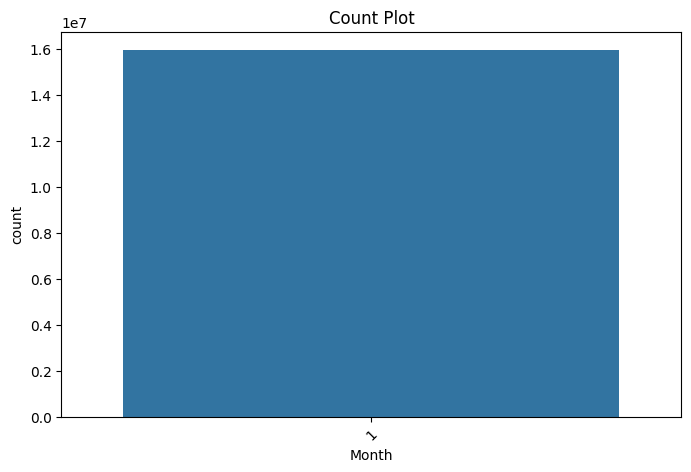

In [76]:
Month_df = df_clean2.groupBy("Month").count().toPandas()


plt.figure(figsize=(8, 5))
sns.barplot(x="Month", y="count", data=Month_df)
plt.title("Count Plot")
plt.xticks(rotation=45)
plt.show()

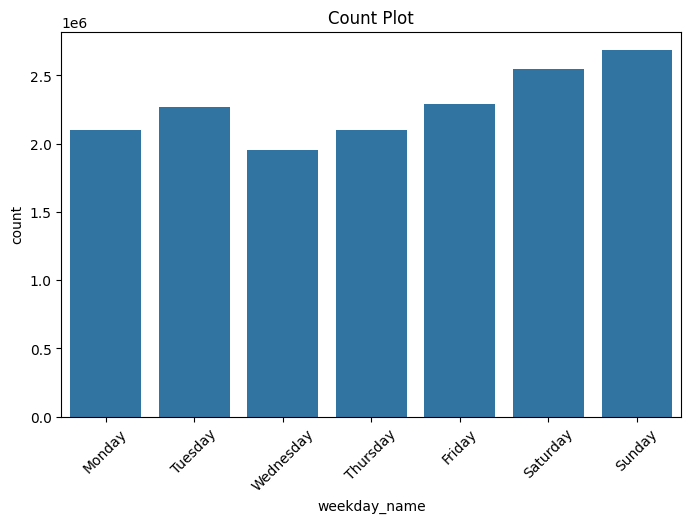

In [77]:
Day_df = df_clean2.groupBy("weekday_name").count().toPandas()
order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8, 5))
sns.barplot(x="weekday_name", y="count", data=Day_df, order=order_days)
plt.title("Count Plot")
plt.xticks(rotation=45)
plt.show()

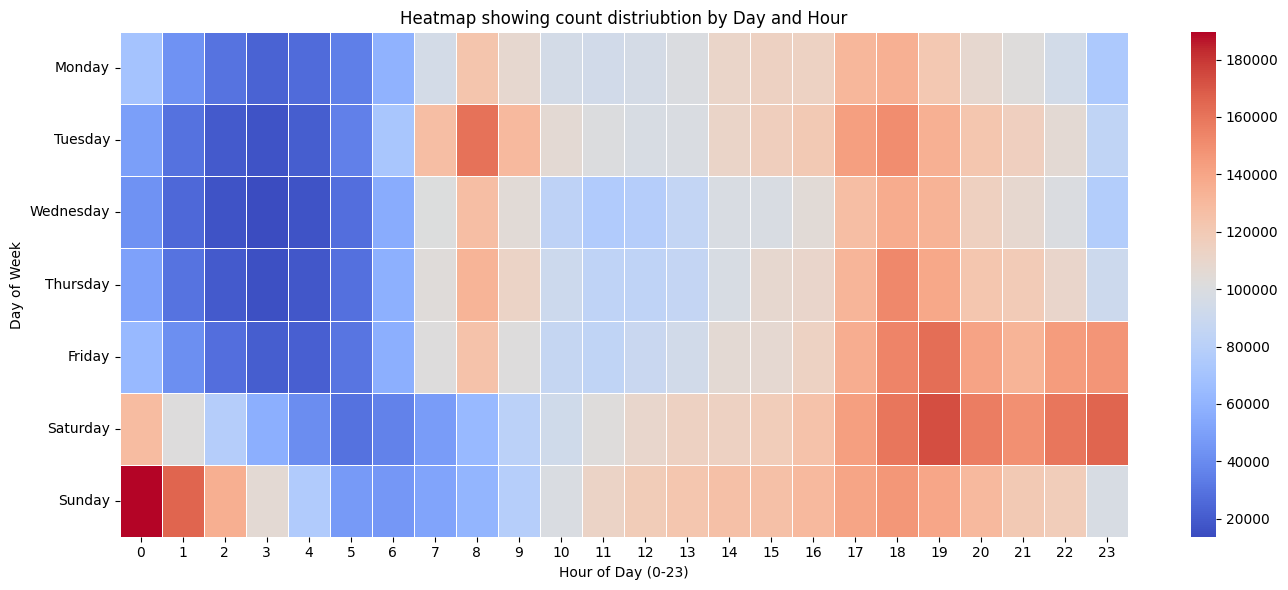

In [81]:
heatmap_df = df_clean2.groupBy("weekday_name", "Hour").count()

pandas = heatmap_df.toPandas()

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pandas["weekday_name"] = pd.Categorical(pandas["weekday_name"], categories=day_order, ordered=True)

pivot_df = pandas.pivot(index="weekday_name", columns="Hour", values="count").fillna(0)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot_df,
    cmap="coolwarm",
    annot=False,
    fmt="g",
    linewidths=0.5
)

plt.title("Heatmap showing count distriubtion by Day and Hour")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

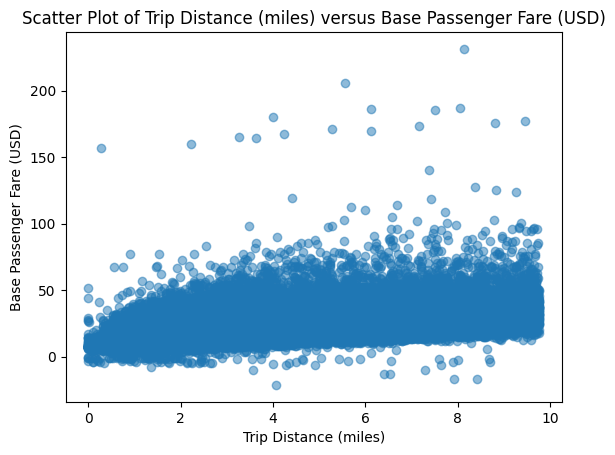

In [82]:
# scatter plot of base fare versus distance
df_sampled = df_clean2.sample(withReplacement=False, fraction=0.01, seed=42)

scatter1_df = df_sampled.select("trip_miles", "base_passenger_fare").toPandas()

plt.scatter(scatter1_df["trip_miles"], scatter1_df["base_passenger_fare"], alpha=0.5)
plt.title("Scatter Plot of Trip Distance (miles) versus Base Passenger Fare (USD)")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Base Passenger Fare (USD)")
plt.show()

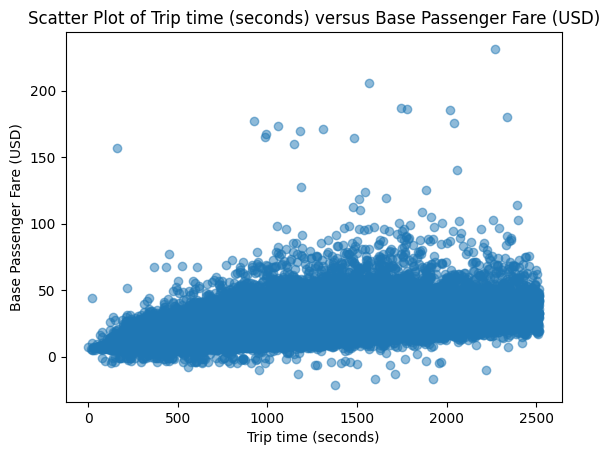

In [83]:
# scatter plot of base versus trip duration
df_sampled = df_clean2.sample(withReplacement=False, fraction=0.01, seed=42)

scatter2_df = df_sampled.select("trip_time", "base_passenger_fare").toPandas()

plt.scatter(scatter2_df["trip_time"], scatter2_df["base_passenger_fare"], alpha=0.5)
plt.title("Scatter Plot of Trip time (seconds) versus Base Passenger Fare (USD)")
plt.xlabel("Trip time (seconds)")
plt.ylabel("Base Passenger Fare (USD)")
plt.show()

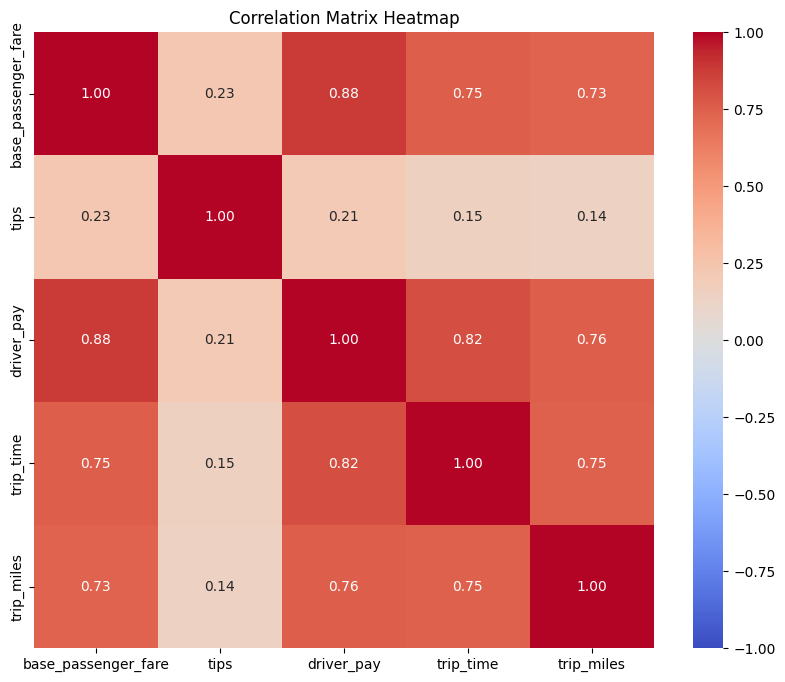

In [87]:
# correlation map
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

cols_corr = ["base_passenger_fare", "tips", "driver_pay", "trip_time", "trip_miles"]

assembler = VectorAssembler(inputCols=cols_corr, outputCol="features")
vector_df = assembler.transform(df_clean2).select("features")

matrix_row = Correlation.corr(vector_df, "features").head()
spark_matrix = matrix_row[0].toArray()

corr_pd_df = pd.DataFrame(spark_matrix, columns=cols_corr, index=cols_corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pd_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


In [90]:
#Average Trip Distance
df_clean2.select(
    F.avg("trip_miles").alias("Average Distance")
).show()

+------------------+
|  Average Distance|
+------------------+
|3.1489887142876114|
+------------------+



In [91]:
#Average Fare
df_clean2.select(
    F.avg("base_passenger_fare").alias("Average Fare")
).show()

+----------------+
|    Average Fare|
+----------------+
|16.7170142214987|
+----------------+



## 1.Setup

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install pyspark -q

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Big_data_project") \
    .getOrCreate()

spark

## 2. Load Files

In [ ]:
from pyspark.sql import functions as F

file_path = "drive/MyDrive/Big_data_project/Data"

df = spark.read.parquet(file_path)


print("Rows:", df.count())
print("Columns:", len(df.columns))
df.printSchema()

## 3. Dataset Characteristics

In [ ]:
df.describe().show()

In [ ]:
df.limit(5).toPandas()

In [ ]:
#Schema
df.printSchema()

In [ ]:
#Data date range
df.select(
    F.min("pickup_datetime"),
    F.max("pickup_datetime")
).show()

In [ ]:
#Dataset Size
import os

total_size = 0

for file in os.listdir("/content"):
    if file.endswith(".parquet"):
        total_size += os.path.getsize("/content/" + file)

print(f"Dataset size: {total_size/(1024**3):.2f} GB")

In [ ]:
#Records per year
df.groupBy(F.year("pickup_datetime").alias("Year")) \
  .count() \
  .orderBy("Year") \
  .show()

## 4. Data Quality Analysis

In [ ]:
#Missing Values
from pyspark.sql.functions import col, when, count

missing = df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
])

missing.show()

In [ ]:
#Duplicate Records
duplicates = df.count() - df.dropDuplicates().count()
print("Duplicate Records:", duplicates)

In [ ]:
#invalid Trip duration
df = df.withColumn(
    "trip_minutes",
    (F.col("dropoff_datetime").cast("long") -
     F.col("pickup_datetime").cast("long"))/60
)

df.filter(F.col("trip_minutes") < 0).count()

## 5. Exploratory Data Analysis (EDA)

In [ ]:
#Total trips
total_trips = df.count()
print(total_trips)

In [ ]:
#Trips by Month
monthly = df.groupBy(
    F.year("pickup_datetime").alias("Year"),
    F.month("pickup_datetime").alias("Month")
).count().orderBy("Year","Month")

monthly.show()

In [ ]:
#PLot
monthly_pd = monthly.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(range(len(monthly_pd)), monthly_pd["count"])
plt.title("Trips Per Month")
plt.ylabel("Trips")
plt.show()

In [ ]:
#Trips per year

from pyspark.sql.functions import year

yearly = df.groupBy(
    year("pickup_datetime").alias("Year")
).count()

yearly.show()

In [ ]:
#PLot
yearly_pd = yearly.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(range(len(yearly_pd)), yearly_pd["count"])
plt.title("Trips Per Month")
plt.ylabel("Trips")
plt.show()

In [ ]:
#Average Trip Distance
df.select(
    F.avg("trip_miles").alias("Average Distance")
).show()

In [ ]:
#Average Fare
df.select(
    F.avg("base_passenger_fare").alias("Average Fare")
).show()

In [ ]:
#Top Pickup Zone
df.groupBy("PULocationID") \
  .count() \
  .orderBy(F.desc("count")) \
  .show(10)

In [ ]:
#Top Drop off zones

df.groupBy("DOLocationID") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(10)

In [ ]:
#Trips by Hour
hourly = df.groupBy(
    F.hour("pickup_datetime").alias("Hour")
).count().orderBy("Hour")

hourly.show()

In [ ]:
#Plot
hour_pd = hourly.toPandas()

plt.figure(figsize=(10,5))
plt.bar(hour_pd["Hour"], hour_pd["count"])
plt.title("Trips by Hour")
plt.show()